LIBRARY

In [2]:
!pip install prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

LOAD DATASET

In [4]:
df = pd.read_csv('/content/BBCA.JK.csv')

KONVERSI & SORT DATE

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

HANDLE VOLUME = 0

In [7]:
df['volume'] = df['volume'].replace(0, np.nan)
df['volume'] = df['volume'].ffill().bfill()

MENGAMBIL VARIABEL

In [8]:
data = df[['Date', 'close']]

VISUALISASI DATA

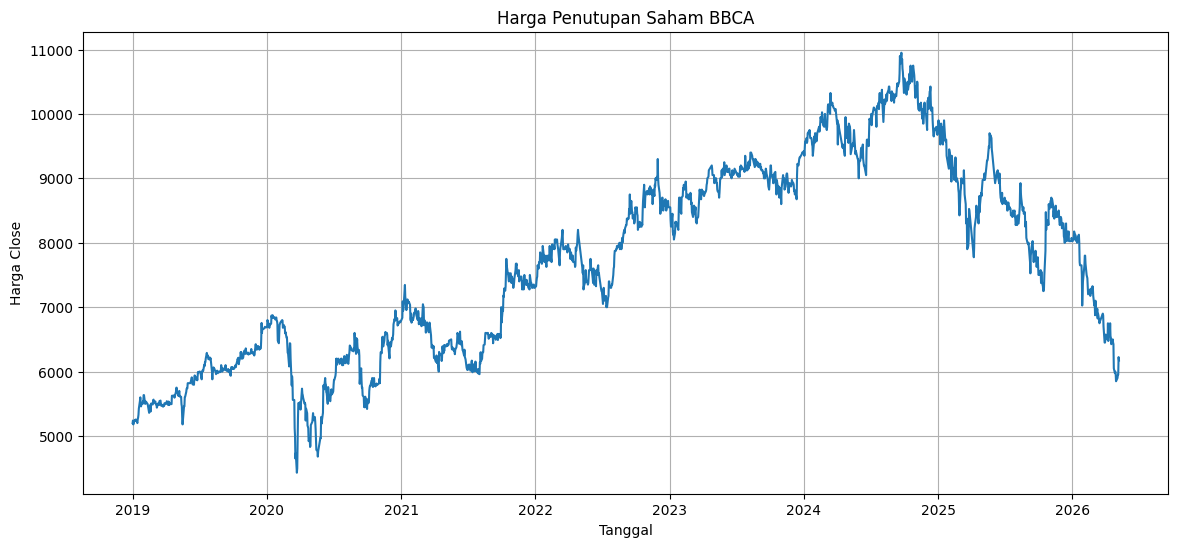

In [9]:
plt.figure(figsize=(14,6))

plt.plot(data['Date'], data['close'])

plt.title('Harga Penutupan Saham BBCA')
plt.xlabel('Tanggal')
plt.ylabel('Harga Close')

plt.grid(True)
plt.show()

UJI STASIONERITAS MENGGUNAKAN ADF TEST

In [10]:
adf_test = adfuller(data['close'])

print("Hasil Augmented Dickey-Fuller Test\n")

print(f"ADF Statistic : {adf_test[0]}")
print(f"p-value       : {adf_test[1]}")
print(f"Jumlah Lag    : {adf_test[2]}")
print(f"Jumlah Data   : {adf_test[3]}")

print("\nCritical Values:")
for key, value in adf_test[4].items():
    print(f"{key} : {value}")


Hasil Augmented Dickey-Fuller Test

ADF Statistic : -1.7121150408243286
p-value       : 0.42488150147509207
Jumlah Lag    : 2
Jumlah Data   : 1783

Critical Values:
1% : -3.434022876868246
5% : -2.8631623708604996
10% : -2.5676336990659903


INTERPRETASI

In [11]:
if adf_test[1] < 0.05:
    print("\nKesimpulan:")
    print("Data sudah stasioner")
else:
    print("\nKesimpulan:")
    print("Data belum stasioner")


Kesimpulan:
Data belum stasioner


FORMAT DATA UNTUK PROPHET
Prophet wajib:
ds = tanggal
y  = target

In [12]:
prophet_data = data.rename(columns={
    'Date': 'ds',
    'close': 'y'
})

============= FORCAST 5 HARI KEDEPAN ===============

out-of-sample forecasting

In [13]:
train = prophet_data[:-5]
test = prophet_data[-5:]

print("\nJumlah Data Train :", len(train))
print("Jumlah Data Test  :", len(test))


Jumlah Data Train : 1781
Jumlah Data Test  : 5


MODEL PROPHET

In [26]:
model = Prophet(
    daily_seasonality=True,
    changepoint_prior_scale=0.2
)

TRAINING MODEL

In [27]:
model.fit(train)


MEMBUAT FUTURE DATA 5 PERIODE TEST

In [28]:
future_test = model.make_future_dataframe(
    periods=5,
    freq='B'
)

FORECASTING TEST

In [29]:
forecast_test = model.predict(future_test)

HASIL FORECAST TEST

In [30]:
forecast_5 = forecast_test[['ds', 'yhat']].tail(5)

EVALUASI MODEL

In [31]:
mae = mean_absolute_error(test['y'], forecast_5['yhat'])

rmse = np.sqrt(
    mean_squared_error(test['y'], forecast_5['yhat'])
)

mape = mean_absolute_percentage_error(
    test['y'],
    forecast_5['yhat']
)

print("\nHasil Evaluasi Prophet\n")

print(f"MAE  : {mae}")
print(f"RMSE : {rmse}")
print(f"MAPE : {mape}")



Hasil Evaluasi Prophet

MAE  : 582.6611369006808
RMSE : 598.0190890720302
MAPE : 0.09699980612315004


VISUALISASI FORECAST TEST

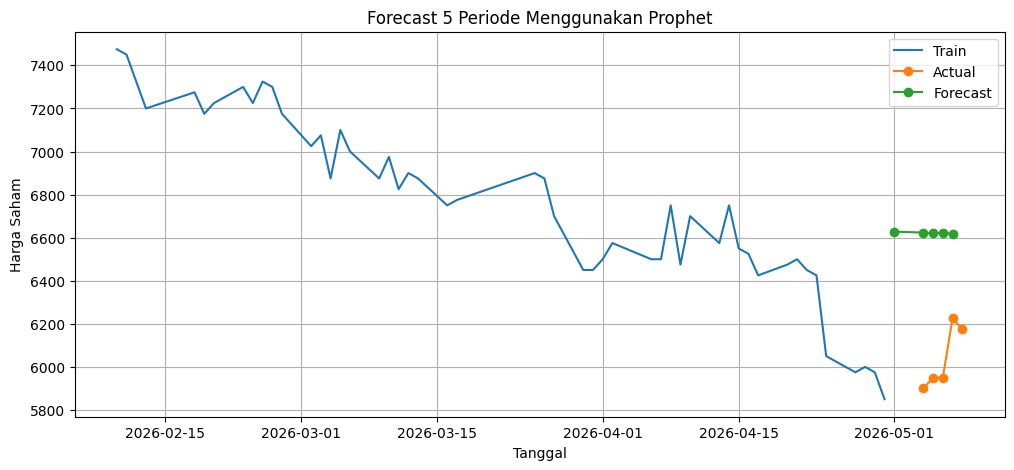

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    train['ds'][-50:],
    train['y'][-50:],
    label='Train'
)

plt.plot(
    test['ds'],
    test['y'],
    marker='o',
    label='Actual'
)

plt.plot(
    forecast_5['ds'],
    forecast_5['yhat'],
    marker='o',
    label='Forecast'
)

plt.title('Forecast 5 Periode Menggunakan Prophet')
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham')

plt.legend()
plt.grid(True)

plt.show()

============= FORCAST 5 BULAN/110 HARI KEDEPAN ===============

In [33]:
future_110 = model.make_future_dataframe(
    periods=110,
    freq='B'
)

forecast_110 = model.predict(future_110)

VISUALISASI FORECAST 5 BULAN

Text(65.72222222222221, 0.5, 'Harga Saham')

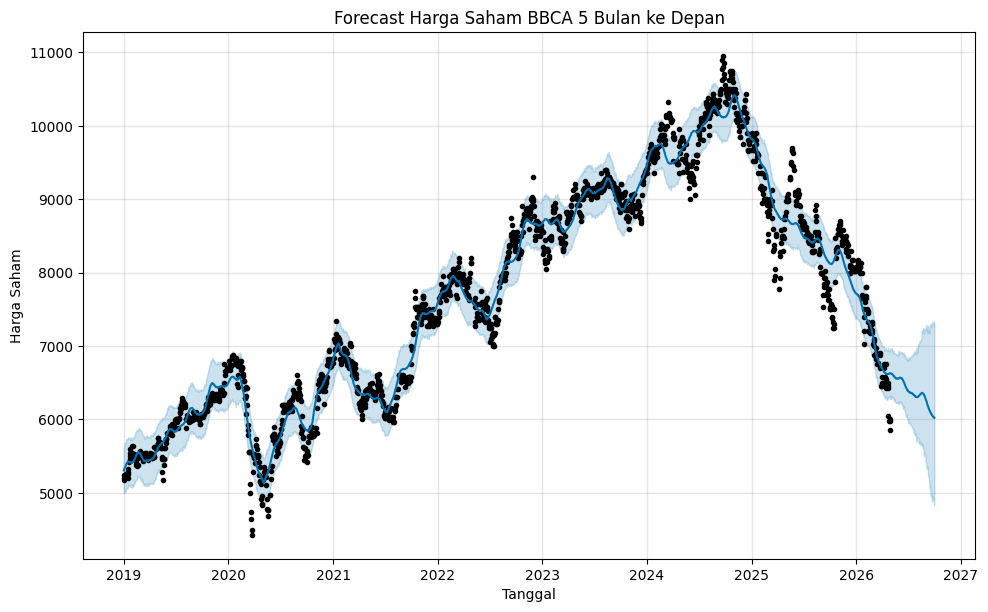

In [45]:
fig = model.plot(forecast_110)

plt.title('Forecast Harga Saham BBCA 5 Bulan ke Depan')
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham')

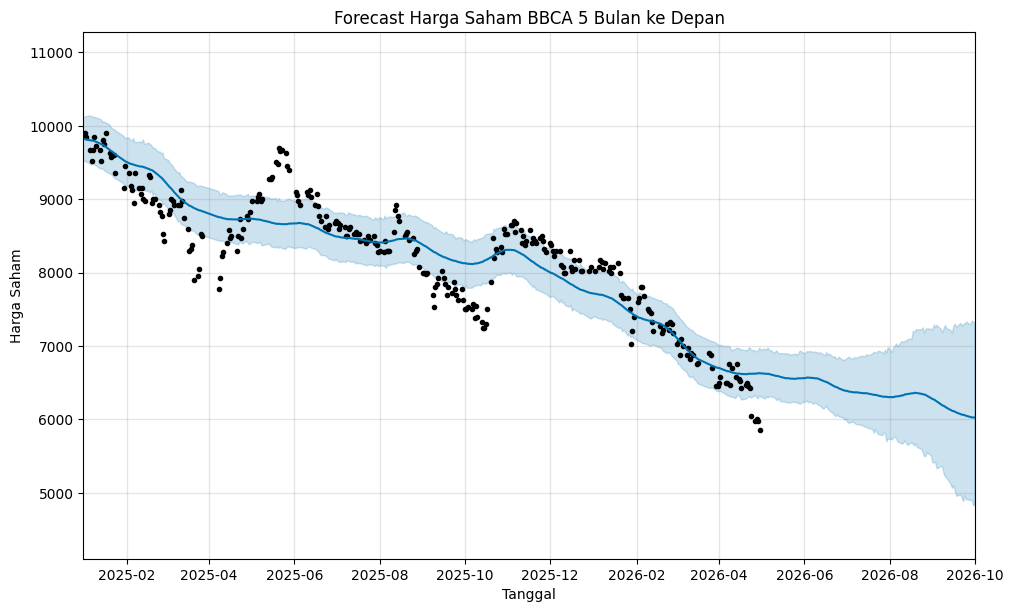

In [53]:
fig = model.plot(forecast_110)

plt.title('Forecast Harga Saham BBCA 5 Bulan ke Depan')
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham')

plt.xlim(
    pd.to_datetime('2025-01-01'),
    pd.to_datetime('2026-10-01')
)

plt.grid(True)

plt.show()

VISUALISASI KOMPONEN PROPHET

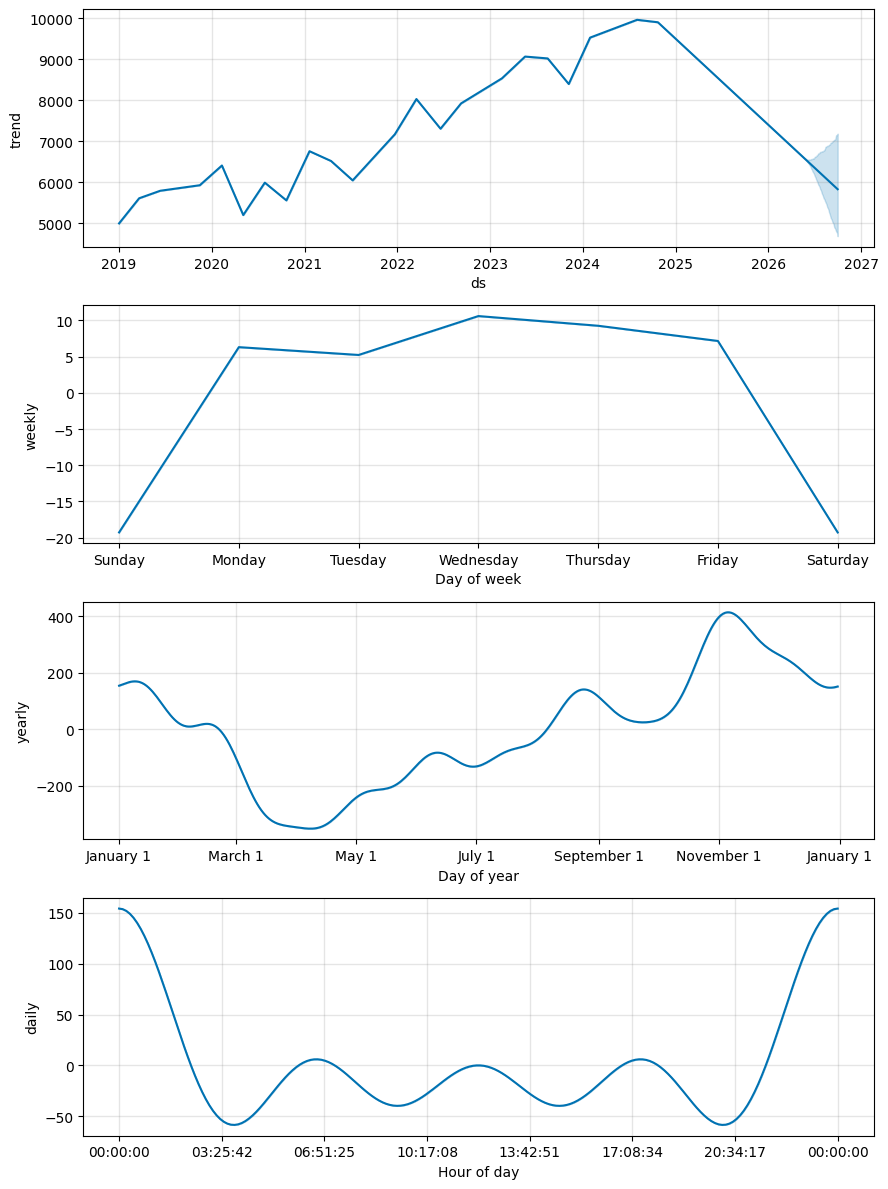

In [54]:
fig2 = model.plot_components(forecast_110)

plt.show()